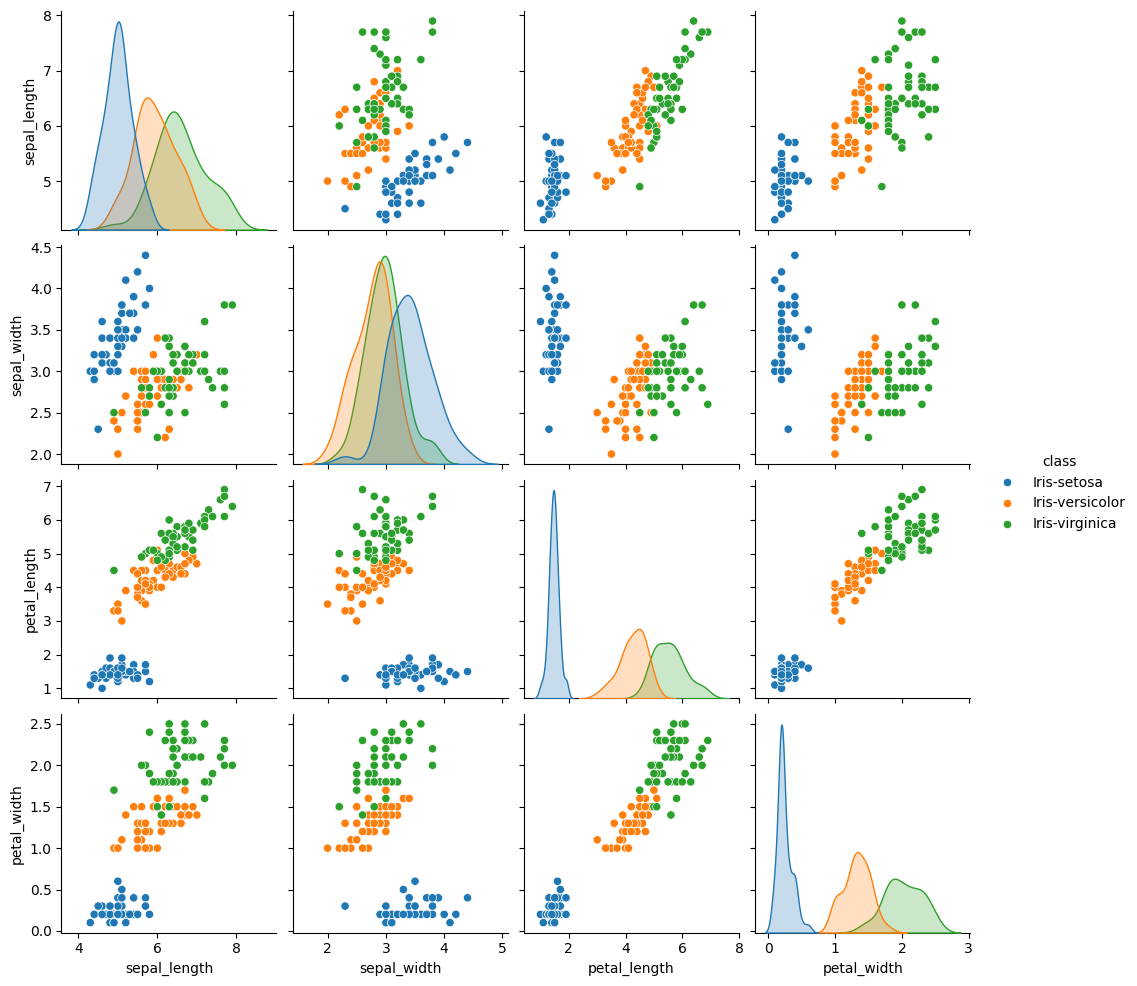

Binary Logistic Regression accuracy: 1.00

Simple Linear Regression - Train MSE: 3.39
Test MSE: 2.61

Polynomial degree 15 - Train MSE: 3.23
Test MSE: 3.20


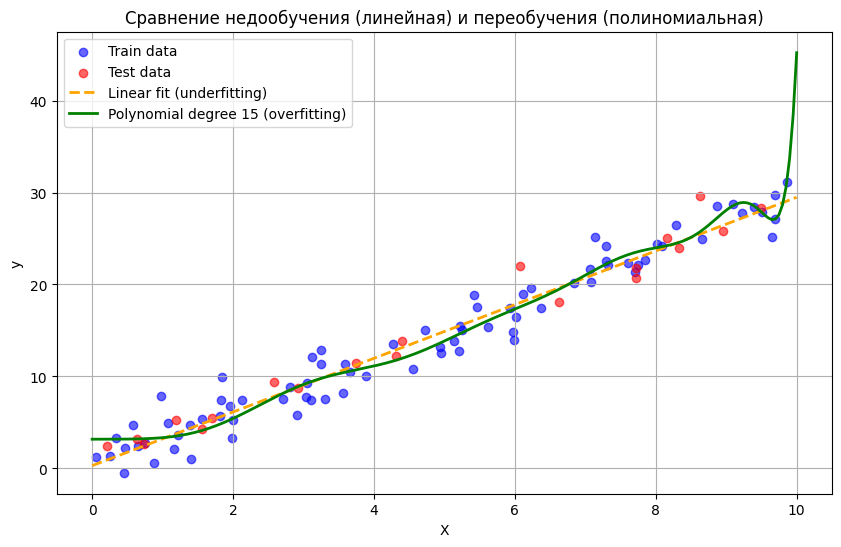

In [1]:
# # LAB01: Iris Analysis and Overfitting Demonstration
# %%
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.pipeline import make_pipeline
from pathlib import Path

# ------------------------------
# 1. Load Iris data
# ------------------------------
# Use pathlib to locate the data file in the same folder as this notebook
current_dir = Path().absolute()
data_path = current_dir / 'iris.data'   # change filename if needed

column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv(data_path, names=column_names)

# ------------------------------
# 2. Pairplot
# ------------------------------
sns.pairplot(df, hue='class', diag_kind='kde')
plt.show()

# ------------------------------
# 3. Binary Logistic Regression
# ------------------------------
binary_df = df[df['class'] != 'Iris-virginica'].copy()
X = binary_df.iloc[:, :-1]
y = binary_df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f'Binary Logistic Regression accuracy: {acc:.2f}')

# ------------------------------
# 4. Overfitting demo with synthetic data
# ------------------------------
np.random.seed(42)
X_syn = np.random.rand(100, 1) * 10
y_syn = 3 * X_syn.squeeze() + np.random.randn(100) * 2

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_syn, y_syn, test_size=0.2, random_state=42)

# Simple linear regression (underfitting)
lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train_s)
y_train_pred = lin_reg.predict(X_train_s)
y_test_pred = lin_reg.predict(X_test_s)
print(f'\nSimple Linear Regression - Train MSE: {mean_squared_error(y_train_s, y_train_pred):.2f}')
print(f'Test MSE: {mean_squared_error(y_test_s, y_test_pred):.2f}')

# Overfitting with polynomial features (degree 15)
degree = 15
overfit_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
overfit_model.fit(X_train_s, y_train_s)
y_train_pred_poly = overfit_model.predict(X_train_s)
y_test_pred_poly = overfit_model.predict(X_test_s)
print(f'\nPolynomial degree {degree} - Train MSE: {mean_squared_error(y_train_s, y_train_pred_poly):.2f}')
print(f'Test MSE: {mean_squared_error(y_test_s, y_test_pred_poly):.2f}')

# ------------------------------
# Plot both fits: linear (orange dashed) and polynomial (green)
# ------------------------------
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
y_plot_linear = lin_reg.predict(X_plot)
y_plot_poly = overfit_model.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_s, y_train_s, label='Train data', alpha=0.6, color='blue')
plt.scatter(X_test_s, y_test_s, label='Test data', alpha=0.6, color='red')
plt.plot(X_plot, y_plot_linear, label='Linear fit (underfitting)', color='orange', linestyle='--', linewidth=2)
plt.plot(X_plot, y_plot_poly, label=f'Polynomial degree {degree} (overfitting)', color='green', linewidth=2)
plt.legend()
plt.title('Сравнение недообучения (линейная) и переобучения (полиномиальная)')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()